In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/atilsamancioglu/MachineLearningNotebooks/refs/heads/main/15-gym_crowdedness.csv')

In [3]:
df.head()
# gym yoğunluk datası

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17


In [4]:
df.info()
#genel olarak temiz bir data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [5]:
df.shape

(62184, 11)

In [6]:
df.columns # bir şeyi değiştirmemize gerek yok

Index(['number_people', 'date', 'timestamp', 'day_of_week', 'is_weekend',
       'is_holiday', 'temperature', 'is_start_of_semester',
       'is_during_semester', 'month', 'hour'],
      dtype='object')

In [7]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


In [8]:
df.isnull().sum() # null değer yok

,0
number_people,0
date,0
timestamp,0
day_of_week,0
is_weekend,0
is_holiday,0
temperature,0
is_start_of_semester,0
is_during_semester,0
month,0


In [9]:
# değiştirmek istersek bir şey date değiştirebiliriz o da düzgün bir şekilde girilmiş yearmonthday şeklinde
# datetime diye bir obje var bunu kullanabilirz
df.date = pd.to_datetime(df.date, utc= True)

In [10]:
df.info() # date, datetime oldu

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   number_people         62184 non-null  int64              
 1   date                  62184 non-null  datetime64[ns, UTC]
 2   timestamp             62184 non-null  int64              
 3   day_of_week           62184 non-null  int64              
 4   is_weekend            62184 non-null  int64              
 5   is_holiday            62184 non-null  int64              
 6   temperature           62184 non-null  float64            
 7   is_start_of_semester  62184 non-null  int64              
 8   is_during_semester    62184 non-null  int64              
 9   month                 62184 non-null  int64              
 10  hour                  62184 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(1), int64(9)
memory usage: 5.2 M

In [11]:
df.head() # dat aynı görünüyoru ama type farklı

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,71.76,0,0,8,17


In [12]:
df.date

,date
0,2015-08-15 00:00:11+00:00
1,2015-08-15 00:20:14+00:00
2,2015-08-15 00:30:15+00:00
3,2015-08-15 00:40:16+00:00
4,2015-08-15 00:50:17+00:00
...,...
62179,2017-03-19 01:42:28+00:00
62180,2017-03-19 01:52:35+00:00
62181,2017-03-19 02:02:40+00:00
62182,2017-03-19 02:12:47+00:00


In [13]:
df['year'] = df['date'].dt.year # sadece yılları getirir
# df.date.dt.month # bunlar zaten var
# df.date.dt.day # bunlar zaten var
# df.date.dt.hour # bunlar zaten var

In [14]:
df['year']

,year
0,2015
1,2015
2,2015
3,2015
4,2015
...,...
62179,2017
62180,2017
62181,2017
62182,2017


In [15]:
df.head()

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,71.76,0,0,8,17,2015
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,71.76,0,0,8,17,2015
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,71.76,0,0,8,17,2015
3,44,2015-08-15 00:40:16+00:00,63616,4,0,0,71.76,0,0,8,17,2015
4,45,2015-08-15 00:50:17+00:00,64217,4,0,0,71.76,0,0,8,17,2015


In [16]:
df.year.unique()

array([2015, 2016, 2017], dtype=int32)

In [17]:
df.drop('date', axis=1, inplace=True)# çok önemli değil gibi drop yapalım

In [18]:
df.head() # date is gone

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,61211,4,0,0,71.76,0,0,8,17,2015
1,45,62414,4,0,0,71.76,0,0,8,17,2015
2,40,63015,4,0,0,71.76,0,0,8,17,2015
3,44,63616,4,0,0,71.76,0,0,8,17,2015
4,45,64217,4,0,0,71.76,0,0,8,17,2015


# **EDA**

/tmp/ipython-input-3048165462.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='hour', y='number_people', ci=None)


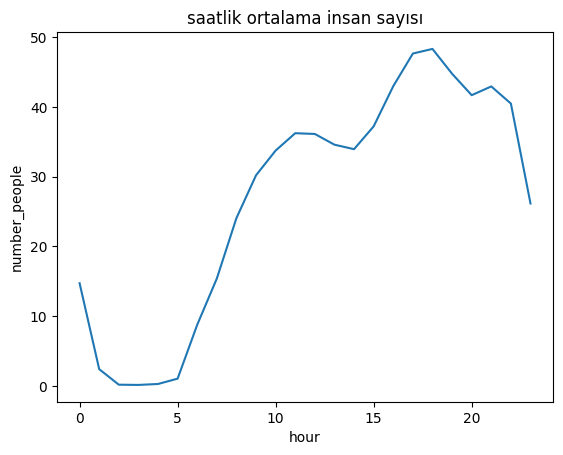

In [19]:
sns.lineplot(data=df, x='hour', y='number_people', ci=None)
plt.title("saatlik ortalama insan sayısı")
plt.show()

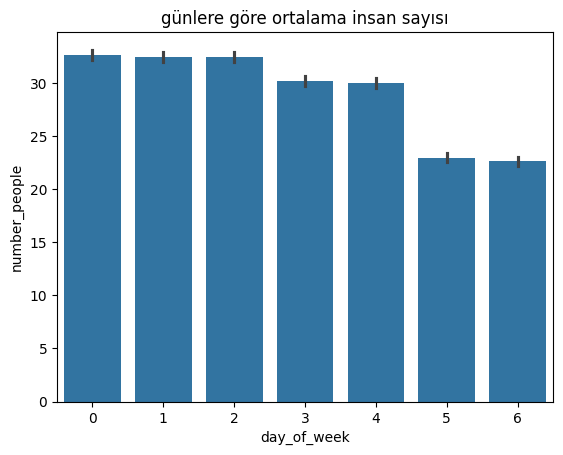

In [20]:
sns.barplot(data=df, x='day_of_week', y='number_people')
plt.title("günlere göre ortalama insan sayısı")
plt.show()

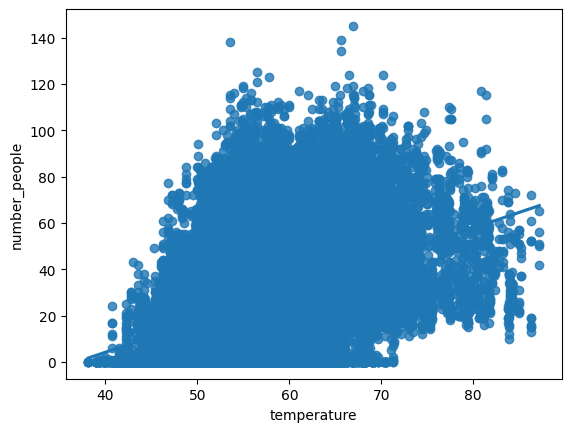

In [21]:
sns.regplot(data=df, x='temperature', y='number_people')
plt.show()

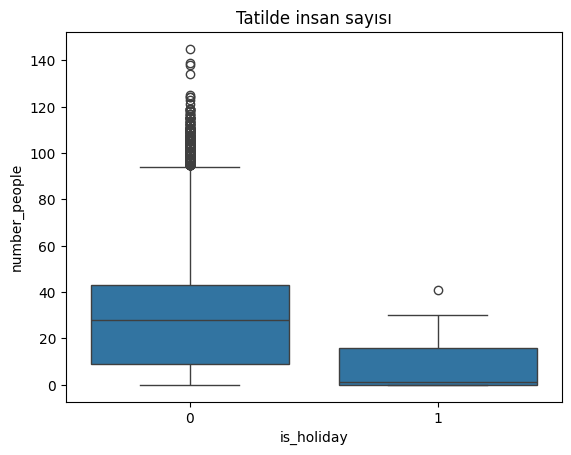

In [22]:
sns.boxplot(data=df, x='is_holiday', y='number_people')
plt.title("Tatilde insan sayısı")
plt.show()

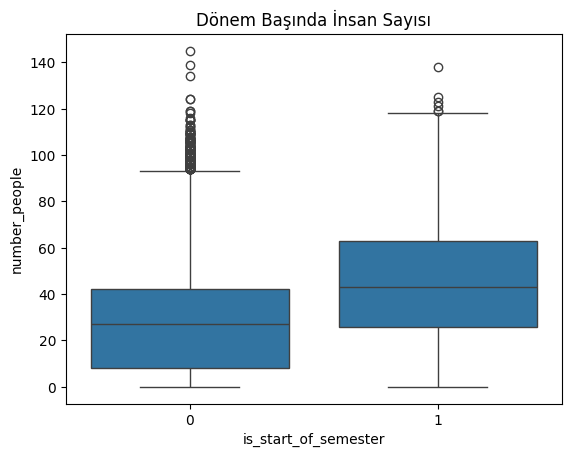

In [23]:
sns.boxplot(data=df, x="is_start_of_semester", y="number_people")
plt.title("Dönem Başında İnsan Sayısı")
plt.show()

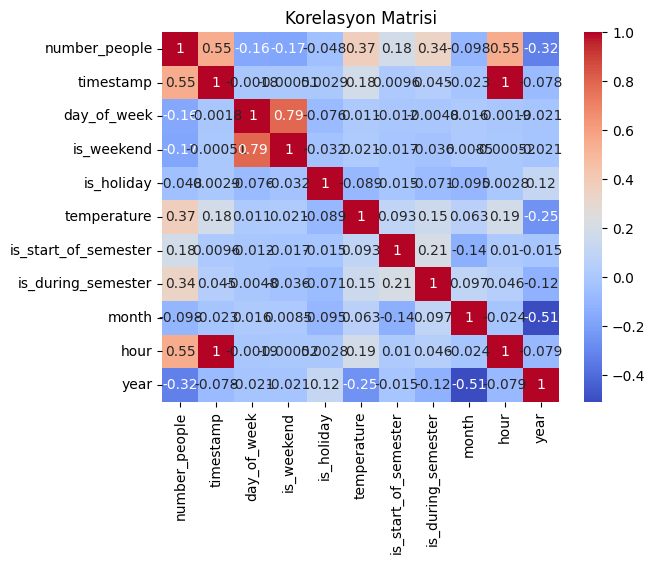

In [24]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Korelasyon Matrisi")
plt.show()

In [25]:
df.corr() # time stampı çıkarmak mantıklı olur

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
number_people,1.000000,0.550218,-0.162062,-0.173958,-0.048249,0.373327,0.182683,0.335350,-0.097854,0.552049,-0.322591
timestamp,0.550218,1.000000,-0.001793,-0.000509,0.002851,0.184849,0.009551,0.044676,-0.023221,0.999077,-0.077767
day_of_week,-0.162062,-0.001793,1.000000,0.791338,-0.075862,0.011169,-0.011782,-0.004824,0.015559,-0.001914,-0.021242
is_weekend,-0.173958,-0.000509,0.791338,1.000000,-0.031899,0.020673,-0.016646,-0.036127,0.008462,-0.000517,-0.021260
is_holiday,-0.048249,0.002851,-0.075862,-0.031899,1.000000,-0.088527,-0.014858,-0.070798,-0.094942,0.002843,0.121129
temperature,0.373327,0.184849,0.011169,0.020673,-0.088527,1.000000,0.093242,0.152476,0.063125,0.185121,-0.249638
is_start_of_semester,0.182683,0.009551,-0.011782,-0.016646,-0.014858,0.093242,1.000000,0.209862,-0.137160,0.010091,-0.015377
is_during_semester,0.335350,0.044676,-0.004824,-0.036127,-0.070798,0.152476,0.209862,1.000000,0.096556,0.045581,-0.124302
month,-0.097854,-0.023221,0.015559,0.008462,-0.094942,0.063125,-0.137160,0.096556,1.000000,-0.023624,-0.508552
hour,0.552049,0.999077,-0.001914,-0.000517,0.002843,0.185121,0.010091,0.045581,-0.023624,1.000000,-0.078816


In [26]:
df.drop('timestamp', axis = 1, inplace=True)

In [27]:
df.head()

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,4,0,0,71.76,0,0,8,17,2015
1,45,4,0,0,71.76,0,0,8,17,2015
2,40,4,0,0,71.76,0,0,8,17,2015
3,44,4,0,0,71.76,0,0,8,17,2015
4,45,4,0,0,71.76,0,0,8,17,2015


### **DEPENDENT & INDEPENDENT FEATURE**

In [29]:
X = df.drop('number_people', axis=1)
y = df['number_people']

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [39]:
def calculate_model_metrics(true, predicted):
  mae = mean_absolute_error(true, predicted)
  mse = mean_squared_error(true, predicted)
  rmse = np.sqrt(mean_squared_error(true, predicted))
  r2 = r2_score(true, predicted)
  return mae, rmse, r2

In [40]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor()
}

In [41]:
for i in range(len(list(models))):
  model = list(models.values())[i]
  model.fit(X_train, y_train)

  y_train_pred = model.predict(X_train) #train datasının scorelarına bakmak için
  y_test_pred = model.predict(X_test)

  model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
  model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

  print(list(models.values())[i])

  print("Evaluation for training set")
  print("RMSE:" , model_train_rmse)
  print("MAE:", model_train_mae)
  print("R2:", model_train_r2)

  print("----------------------------------------------------")

  print("Evaluation for test set")
  print("RMSE:" , model_test_rmse)
  print("MAE:", model_test_mae)
  print("R2:", model_test_r2)

  print("----------------------------------------------------")
  print("\n")

LinearRegression()
Evaluation for training set
RMSE: 14.322500408269727
MAE: 10.733469936454322
R2: 0.5999639521710998
----------------------------------------------------
Evaluation for test set
RMSE: 14.45063290337055
MAE: 10.779752371029556
R2: 0.5989271376662775
----------------------------------------------------


Lasso()
Evaluation for training set
RMSE: 14.569122351126817
MAE: 10.945189874221992
R2: 0.5860687429058037
----------------------------------------------------
Evaluation for test set
RMSE: 14.703511215751082
MAE: 10.970594902476913
R2: 0.5847671974050243
----------------------------------------------------


Ridge()
Evaluation for training set
RMSE: 14.322500413912243
MAE: 10.733479178820698
R2: 0.5999639518559021
----------------------------------------------------
Evaluation for test set
RMSE: 14.450633329986024
MAE: 10.779759559023008
R2: 0.5989271139851151
----------------------------------------------------


KNeighborsRegressor()
Evaluation for training set
RMSE

In [42]:
# yukarıdaki modellerden RandomForestRegressor() en yüksek skoru verdi

hyperparameter tuning

In [43]:
knn_params = {"n_neighbors": [2,3,10,20,40,50]}
rf_params = {
    "max_depth": [5,8,10,15,None],
    "max_features": ["sqrt", "log2", 5,7,10],
    "min_samples_split": [2,8,12,20],
    "n_estimators": [100,200,500,1000]
}


In [44]:
from sklearn.model_selection import RandomizedSearchCV

In [45]:
randomcv_models = [
    ("KNN", KNeighborsRegressor(), knn_params),
    ("RF", RandomForestRegressor(), rf_params)
    ]

In [48]:
for name, model, params in randomcv_models:
  randomcv= RandomizedSearchCV(estimator=model, param_distributions=params, cv=3, n_iter=100, n_jobs=-1)
  randomcv.fit(X_train, y_train)

  print("Best params for :", name, randomcv.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=100. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params for : KNN {'n_neighbors': 2}


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

In [52]:
# üstteki satır çok zaman aldı (çalıştırmayı yarıda kestim ve sonucu videodan aldım)
# Best params for : KNN {'n_neighbors' :2}
# Best params for : RF {'n_estimators' :500 , 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}

In [54]:
models = {
    "KNeighborsRegressor": KNeighborsRegressor(n_neighbors=2),
    "RandomForestRegressor": RandomForestRegressor( n_estimators =500 ,
                                                   min_samples_split= 2,
                                                   max_features= 7,
                                                   max_depth= None)
}

In [55]:
# şimdi sadece yukarıdaki iki modelle fit yapacak ve scores bulacak
for i in range(len(list(models))):
  model = list(models.values())[i]
  model.fit(X_train, y_train)

  y_train_pred = model.predict(X_train) #train datasının scorelarına bakmak için
  y_test_pred = model.predict(X_test)

  model_train_mae, model_train_rmse, model_train_r2 = calculate_model_metrics(y_train, y_train_pred)
  model_test_mae, model_test_rmse, model_test_r2 = calculate_model_metrics(y_test, y_test_pred)

  print(list(models.values())[i])

  print("Evaluation for training set")
  print("RMSE:" , model_train_rmse)
  print("MAE:", model_train_mae)
  print("R2:", model_train_r2)

  print("----------------------------------------------------")

  print("Evaluation for test set")
  print("RMSE:" , model_test_rmse)
  print("MAE:", model_test_mae)
  print("R2:", model_test_r2)

  print("----------------------------------------------------")
  print("\n")

KNeighborsRegressor(n_neighbors=2)
Evaluation for training set
RMSE: 5.454993844683391
MAE: 3.5539474248466916
R2: 0.9419703473309985
----------------------------------------------------
Evaluation for test set
RMSE: 6.906672567075778
MAE: 4.636208671040782
R2: 0.9083806355016093
----------------------------------------------------




KeyboardInterrupt: 